<a href="https://colab.research.google.com/github/syeda293/dynamic-loan-pricing/blob/main/rl_pricing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/syeda293/dynamic-loan-pricing.git
%cd dynamic-loan-pricing
!pip install -q -r requirements.txt

Cloning into 'dynamic-loan-pricing'...
remote: Enumerating objects: 26, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 26 (delta 2), reused 18 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (26/26), 8.63 KiB | 2.88 MiB/s, done.
Resolving deltas: 100% (2/2), done.
/content/dynamic-loan-pricing
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 87.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 80.6 MB/s eta 0:00:00


In [2]:
from src.data import load_data, split
from src.pd_model import train_pd

df = load_data()
X_tr, X_te, y_tr, y_te = split(df)
model, auc = train_pd(X_tr, y_tr, X_te, y_te)
print("AUC:", auc)

pds = model.predict_proba(X_te)[:, 1]
amounts = X_te["credit_amount"].values
print(len(pds), pds[:5], amounts[:5])

[LightGBM] [Info] Number of positive: 240, number of negative: 560
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000437 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 412
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.300000 -> initscore=-0.847298
[LightGBM] [Info] Start training from score -0.847298
AUC: 0.800595238095238
200 [0.13606996 0.04107172 0.84681021 0.2401569  0.08722088] [1913 1860 1024 3104 2520]


In [3]:
from src.train_rl import train, evaluate, fixed_policy

ppo = train(pds, amounts, steps=50_000)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

In [4]:
rl_policy = lambda obs: int(ppo.predict(obs, deterministic=True)[0])

rl_score = evaluate(rl_policy, pds, amounts, n=20000)
fixed_score = evaluate(fixed_policy, pds, amounts, n=20000)

print("Fixed 15% avg reward:", round(fixed_score, 4))
print("RL pricing avg reward:", round(rl_score, 4))

Fixed 15% avg reward: -0.2505
RL pricing avg reward: 0.0435


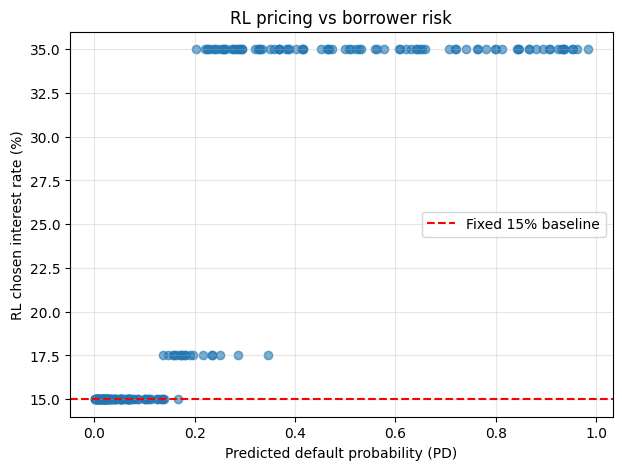

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
from src.pricing_env import LoanPricingEnv

obs = np.column_stack([pds, np.minimum(amounts / 20000, 1)]).astype(np.float32)
actions, _ = ppo.predict(obs, deterministic=True)
chosen_rates = LoanPricingEnv.RATES[actions] * 100

plt.figure(figsize=(7, 5))
plt.scatter(pds, chosen_rates, alpha=0.6)
plt.axhline(15, color="red", linestyle="--", label="Fixed 15% baseline")
plt.xlabel("Predicted default probability (PD)")
plt.ylabel("RL chosen interest rate (%)")
plt.title("RL pricing vs borrower risk")
plt.legend()
plt.grid(alpha=0.3)

os.makedirs("assets", exist_ok=True)
plt.savefig("assets/rl_pricing.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
import pandas as pd
pd.DataFrame({
    "Strategy": ["Fixed 15%", "RL pricing"],
    "Avg reward per loan": [round(fixed_score, 4), round(rl_score, 4)],
})

,Strategy,Avg reward per loan
0,Fixed 15%,-0.2505
1,RL pricing,0.0435


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
